# 9.6: Concise Implementation of Recurrent Neural Networks

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

## 9.6.1: Defining the Model

In [3]:
class RNN(d2l.Module): #@save
    """The RNN model implemented with high-level APIs."""
    def __init__(self, num_inputs, num_hiddens):
        super().__init__()
        self.save_hyperparameters()
        self.rnn = nn.RNN(num_inputs, num_hiddens) # 1 layer by default

    def forward(self, inputs, H=None):
        return self.rnn(inputs, H)

In [4]:
class RNNLM(d2l.RNNLMScratch): #@save
    """The RNN-based language model implemented with high-level APIs.
    Inherits functions from d2l.RNNLMScratch"""
    def init_params(self):
        self.linear = nn.LazyLinear(self.vocab_size)

    def output_layer(self, hiddens):
        return self.linear(hiddens).swapaxes(0,1)

## 9.6.2: Training and Predicting

In [5]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(rnn, vocab_size=len(data.vocab), lr=1)
model.predict('it has', 20, data.vocab)

c:\Users\Py Torch\.conda\envs\d2l\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


'it haskvioioioioiooiooiooi'

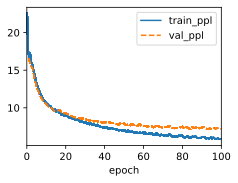

In [6]:
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [7]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has and have in and the'

# Summary

* High level APIs in deep learning frameworks provide implementations of standard RNNs, helping us avoid wasitng time on reimplementation
* Framework implementations are highly optimized, leading to significant computational performance gains compared to implementations from scratch.